# 1.0 Imports

### 1.1 Libs

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import inflection
import warnings
warnings.filterwarnings('ignore')
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.base.model import GenericLikelihoodModel

### 1.2 Functions

In [2]:
def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2))

def elasticity_gauss(P, mu, sigma):
    return -(P * (P - mu)) / (sigma**2)

### 1.3 Loading data

In [3]:
df_raw = pd.read_csv('../datasets/df_ready.csv', encoding='unicode_escape', low_memory=False)

In [4]:
df_raw.head().T

,0,1,2,3,4
Unnamed: 0,4,5,6,7,8
Date_imp,2017-12-14 06:00:00,2017-09-08 05:00:00,2017-10-24 04:00:00,2017-08-15 15:00:00,2017-09-14 21:00:00
Date_imp_d,2017/12/14,2017/09/08,2017/10/24,2017/08/15,2017/09/14
Cluster,35,35,35,35,35
Category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...
price,69.0,69.0,66.0,74.99,69.99
disc_price,64.99,69.0,66.0,74.99,69.99
merchant,Walmart.com,Walmart.com,Walmart.com,Walmart.com,Walmart.com
condition,New,New,New,New,New


# 2.0 Descrição dos dados

In [5]:
df1 = df_raw.copy()

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23151 entries, 0 to 23150
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       23151 non-null  int64  
 1   Date_imp         23151 non-null  object 
 2   Date_imp_d       23151 non-null  object 
 3   Cluster          23151 non-null  int64  
 4   Category_name    23151 non-null  object 
 5   name             23151 non-null  object 
 6   price            23151 non-null  float64
 7   disc_price       23151 non-null  float64
 8   merchant         23151 non-null  object 
 9   condition        23151 non-null  object 
 10  Disc_percentage  23151 non-null  float64
 11  isSale           23151 non-null  object 
 12  Imp_count        23151 non-null  int64  
 13  brand            23151 non-null  object 
 14  p_description    23151 non-null  object 
 15  currency         23151 non-null  object 
 16  dateAdded        23151 non-null  object 
 17  dateSeen    

### 2.1 Renomear colunas

In [7]:
cols_old = ['Unnamed: 0', 'Date_imp', 'Date_imp_d', 'Cluster', 'Category_name', 'name', 'price', 'disc_price', 
       'merchant', 'condition', 'Disc_percentage', 'isSale', 'Imp_count', 'brand', 'p_description',
       'currency', 'dateAdded', 'dateSeen', 'dateUpdated', 'imageURLs', 'manufacturer', 'shipping', 'sourceURLs', 
       'weight', 'Date_imp_d.1', 'Day_n', 'month', 'month_n', 'day', 'Week_Number', 'Zscore_1', 'price_std']

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))
df1.columns = cols_new

### 2.2 Check NA

In [8]:
df1.isna().sum()

unnamed: 0             0
date_imp               0
date_imp_d             0
cluster                0
category_name          0
name                   0
price                  0
disc_price             0
merchant               0
condition              0
disc_percentage        0
is_sale                0
imp_count              0
brand                  0
p_description          0
currency               0
date_added             0
date_seen              0
date_updated           0
image_ur_ls        22696
manufacturer       10639
shipping           11497
source_ur_ls        4930
weight                68
date_imp_d.1           0
day_n                  0
month                  0
month_n                0
day                    0
week_number            0
zscore_1             171
price_std              0
dtype: int64

### 2.3 Linhas duplicadas

In [9]:
linhas_duplicadas = df1[df1.duplicated(keep=False)].index
print("Linhas duplicadas:")
print(linhas_duplicadas)

Linhas duplicadas:
Index([], dtype='int64')


### 2.4 Change types

In [10]:
df1['date_imp'] = pd.to_datetime(df1['date_imp'])
df1['date_added'] = pd.to_datetime(df1['date_added'])
#df1['date_seen'] = pd.to_datetime(df1['date_seen'])
df1['date_updated'] = pd.to_datetime(df1['date_updated'])

### 2.5 Estatística Descritiva

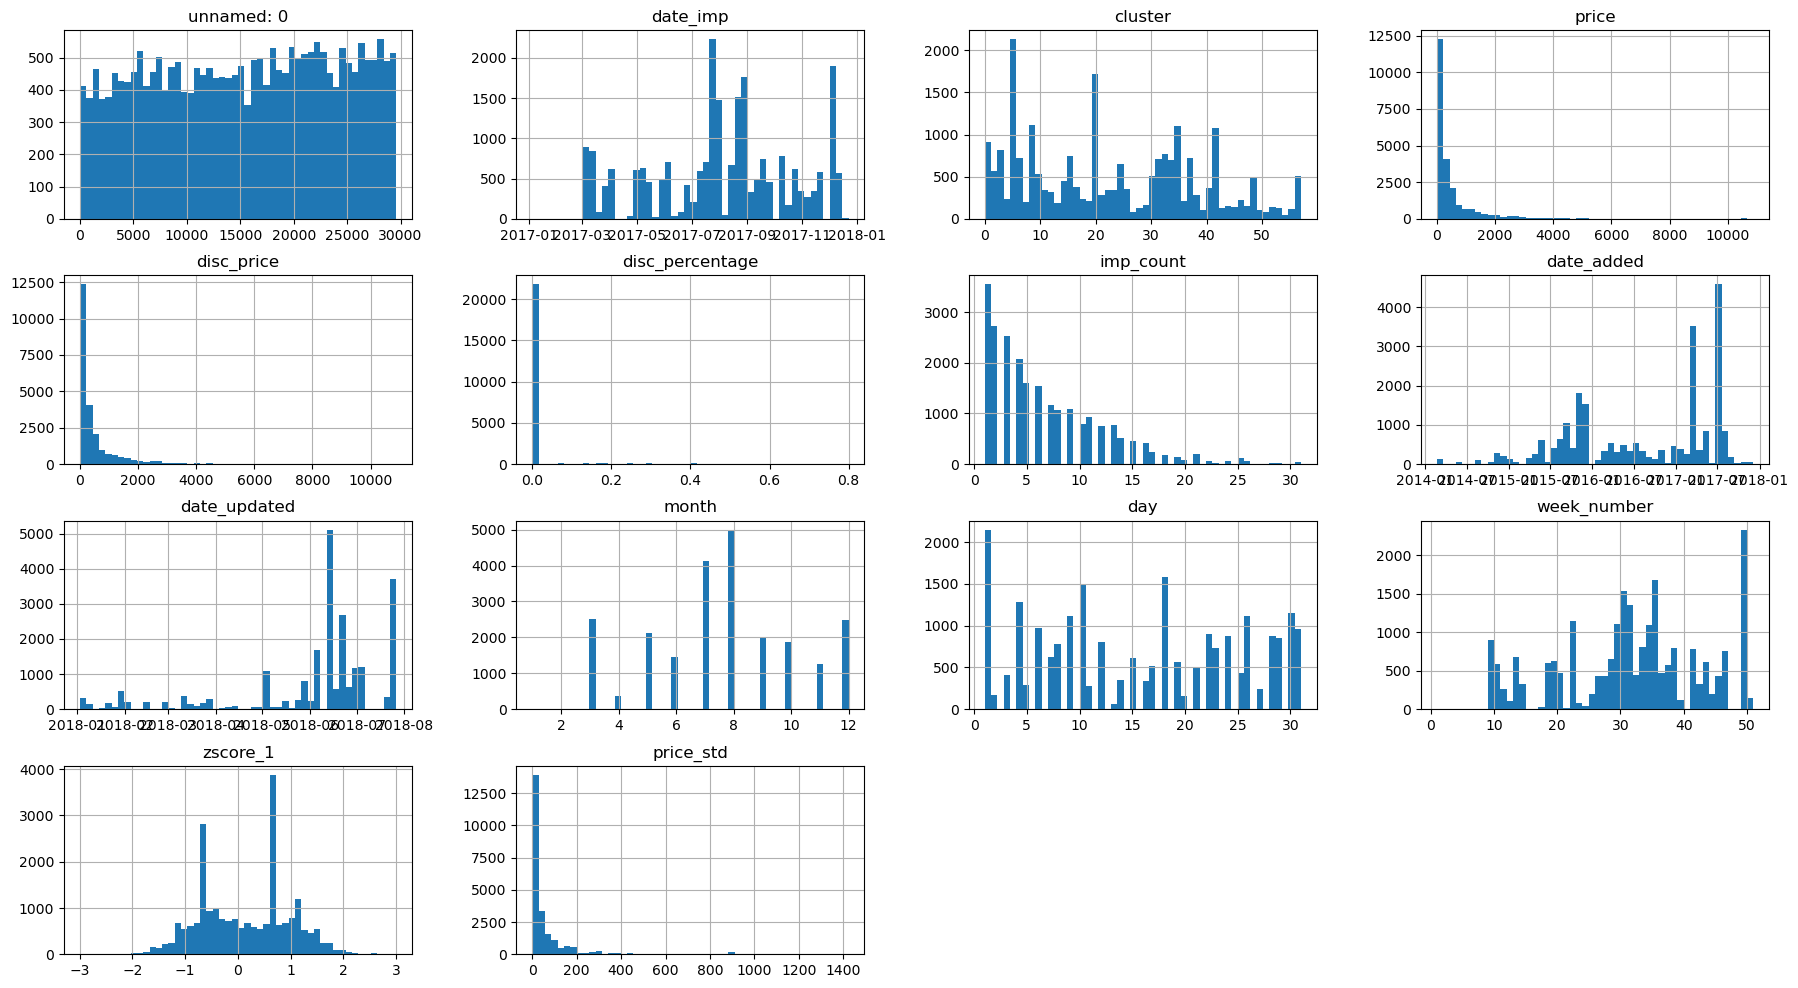

In [11]:
df1.hist(bins=50, figsize=(22,12));

In [12]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude =['int64', 'float64', 'datetime64[ns]'])

### 2.5.1 Atributos numéricos

In [13]:
stat_desc = df1.describe().T
stat_desc

,count,mean,min,25%,50%,75%,max,std
unnamed: 0,23151.0,15338.318431,4.0,7897.5,15613.0,22678.0,29592.0,8528.805636
date_imp,23151,2017-08-05 09:49:29.444084224,2017-01-05 00:00:00,2017-06-09 15:00:00,2017-08-10 00:00:00,2017-09-24 07:00:00,2017-12-22 06:00:00,NaN
cluster,23151.0,22.682735,0.0,8.0,20.0,35.0,57.0,15.576818
price,23151.0,513.037803,1.0,82.99,199.99,540.0,10879.95,859.110002
disc_price,23151.0,494.104295,1.0,79.99,199.0,516.49,10879.95,808.588973
disc_percentage,23151.0,0.016933,0.0,0.0,0.0,0.0,0.8,0.077849
imp_count,23151.0,6.560926,1.0,2.0,5.0,10.0,31.0,5.403166
month,23151.0,7.65103,1.0,6.0,8.0,9.0,12.0,2.592843
day,23151.0,15.693879,1.0,7.0,16.0,24.0,31.0,9.681622
week_number,23151.0,31.34275,1.0,23.0,32.0,38.0,51.0,11.316498


### 2.5.2 Atributos categóricos

In [14]:
cat_attributes.apply(lambda x: x.unique().shape[0])

date_imp_d        188
category_name      58
name              908
merchant            7
condition           1
is_sale             2
brand             266
p_description     908
currency            1
date_added        872
date_seen        4373
date_updated      819
image_ur_ls         5
manufacturer      236
shipping           69
source_ur_ls     3923
weight            640
date_imp_d.1      188
day_n               7
month_n            11
dtype: int64

### 2.6 Comparação das colunas 'price' e 'disc_price'

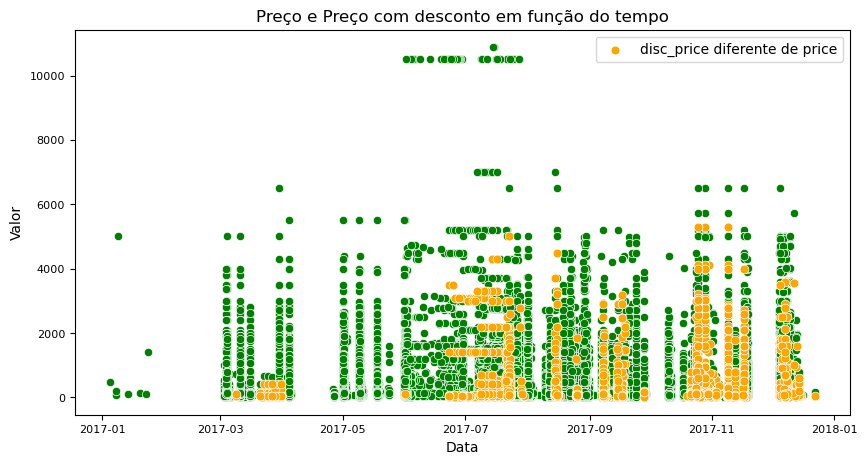

In [15]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df1, x='date_imp', y='price', color='green')
sns.scatterplot(data=df1[df1['price'] != df1['disc_price']], x='date_imp', y='disc_price',
    color='orange', s=40, marker='o', label='disc_price diferente de price')

plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Preço e Preço com desconto em função do tempo')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend()
plt.show()

### 2.7 Seleção de colunas

In [16]:
cols_drop = ['unnamed: 0', 'cluster', 'imp_count', 'zscore_1', 'price_std', 'date_imp_d', 'condition', 'is_sale',
            'currency', 'date_added', 'date_seen', 'date_updated', 'image_ur_ls', 'shipping', 'source_ur_ls', 
            'weight', 'date_imp_d.1']
df1 = df1.drop(cols_drop, axis=1)

In [17]:
df1.head().T

,0,1,2,3,4
date_imp,2017-12-14 06:00:00,2017-09-08 05:00:00,2017-10-24 04:00:00,2017-08-15 15:00:00,2017-09-14 21:00:00
category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...
price,69.0,69.0,66.0,74.99,69.99
disc_price,64.99,69.0,66.0,74.99,69.99
merchant,Walmart.com,Walmart.com,Walmart.com,Walmart.com,Walmart.com
disc_percentage,0.06,0.0,0.0,0.0,0.0
brand,Boytone,Boytone,Boytone,Boytone,Boytone
p_description,"Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ..."
manufacturer,Boytone,Boytone,Boytone,Boytone,Boytone


# 3.0 Análise Exploratória dos Dados (EDA)

In [18]:
df2 = df1.copy()

### Quantidade de produtos vendidos por categoria

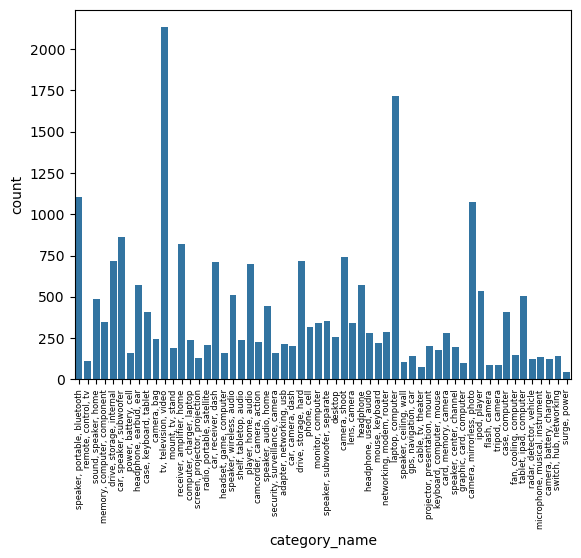

In [19]:
sns.countplot(data=df2, x='category_name');
plt.xticks(rotation=90)
plt.tick_params(axis='x', labelsize=6)
plt.show()

### Quantidade de produtos vendidos por marca para as categorias com maior número de vendas

In [20]:
aux = df2[df2['category_name'] == 'tv, television, video']
aux1 = df2[df2['category_name'] == 'laptop, computer']
aux2 = df2[df2['category_name'] == 'speaker, portable, bluetooth']

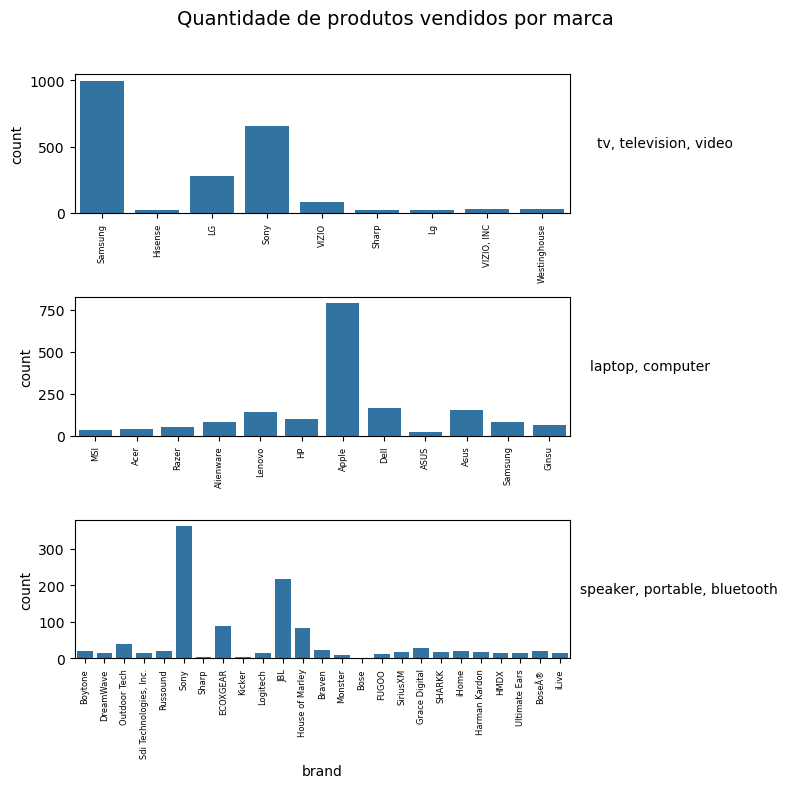

In [21]:
plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
sns.countplot(data=aux, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "tv, television, video", va="center", ha="left", fontsize=10)  # Colocar texto da categoria ao lado, centralizado verticalmente

plt.subplot(3, 1, 2)
sns.countplot(data=aux1, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "laptop, computer", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 3)
sns.countplot(data=aux2, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("brand")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "speaker, portable, bluetooth", va="center", ha="left", fontsize=10)

plt.suptitle("Quantidade de produtos vendidos por marca", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Quantidade de produtos vendidos por merchant para as categorias com maior número de vendas

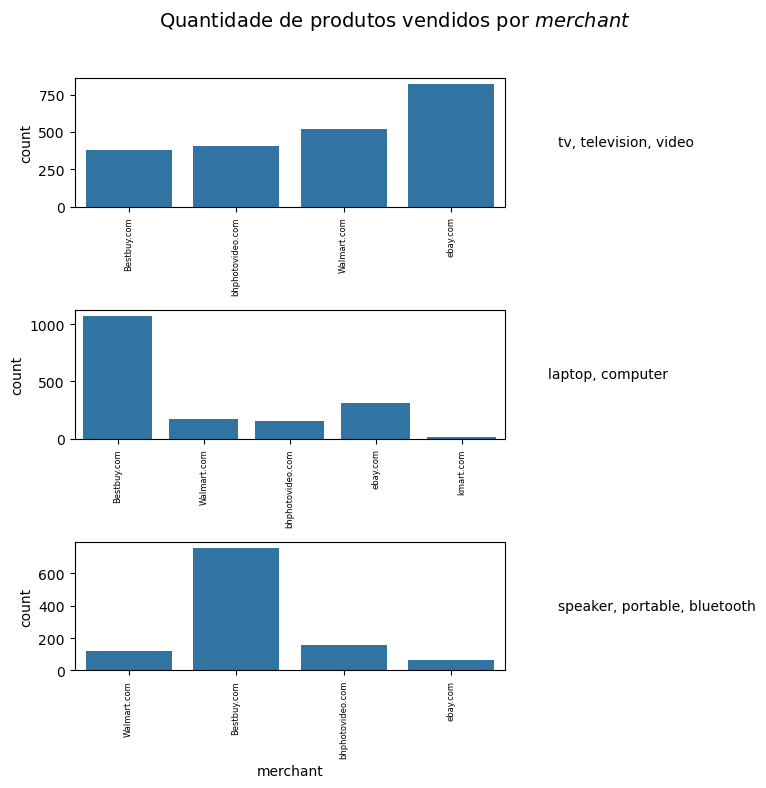

In [22]:
plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
sns.countplot(data=aux, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "tv, television, video", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 2)
sns.countplot(data=aux1, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "laptop, computer", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 3)
sns.countplot(data=aux2, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("merchant")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "speaker, portable, bluetooth", va="center", ha="left", fontsize=10)

plt.suptitle("Quantidade de produtos vendidos por $\t{merchant}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Para a categoria $tv, television, video$

In [23]:
aux = df2[(df2['category_name'] == 'tv, television, video') & (df2['merchant'] == 'ebay.com')]
aux.head().T

,1720,1721,1722,1723,1724
date_imp,2017-06-06 03:00:00,2017-06-08 05:00:00,2017-06-07 02:00:00,2017-06-06 14:00:00,2017-06-07 02:00:00
category_name,"tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video"
name,LG - 75 Class - LED - UJ6470 Series - 2160p - ...,LG - 75 Class - LED - UJ6470 Series - 2160p - ...,LG - 75 Class - LED - UJ6470 Series - 2160p - ...,LG - 75 Class - LED - UJ6470 Series - 2160p - ...,LG - 75 Class - LED - UJ6470 Series - 2160p - ...
price,2496.99,2496.99,2496.99,2496.99,2496.99
disc_price,2496.99,2496.99,2496.99,2496.99,2496.99
merchant,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com
disc_percentage,0.0,0.0,0.0,0.0,0.0
brand,LG,LG,LG,LG,LG
p_description,"4K Ultra HD TVs,TV, Video & Home Audio,Frys,El...","4K Ultra HD TVs,TV, Video & Home Audio,Frys,El...","4K Ultra HD TVs,TV, Video & Home Audio,Frys,El...","4K Ultra HD TVs,TV, Video & Home Audio,Frys,El...","4K Ultra HD TVs,TV, Video & Home Audio,Frys,El..."
manufacturer,NaN,NaN,NaN,NaN,NaN


In [24]:
# quantidade de cada produto dentro do categoria de tv, television e video
aux.groupby('name').count()

,date_imp,category_name,price,disc_price,merchant,disc_percentage,brand,p_description,manufacturer,day_n,month,month_n,day,week_number
name,,,,,,,,,,,,,,
"Details About Samsung 55 Class 4k (2160p) Smart Led Tv (un55mu7000fxza)""",11,11,11,11,11,11,11,11,0,11,11,11,11,11
Details About Samsung Electronics Un49mu8000 49inch 4k (2160p) Uhd Led Lcd Internet Smart Tv,19,19,19,19,19,19,19,19,0,19,19,19,19,19
Details About Sony Kd43x720e 43inch 4k Ultra Hd Smart Led Tv (2017 Model) Kd43x720e,30,30,30,30,30,30,30,30,0,30,30,30,30,30
Details About Sony Kd70x690e 70inch 4k Ultra Hd Smart Led Tv (2017 Model),5,5,5,5,5,5,5,5,0,5,5,5,5,5
"Hisense - 55 Class - LED - H8 Series - 2160p - Smart - 4K UHD TV with HDR""",4,4,4,4,4,4,4,4,4,4,4,4,4,4
J5205 32-Class Full HD Smart LED TV,22,22,22,22,22,22,22,22,22,22,22,22,22,22
"LG - 28 Class (27.5"" Diag.) - LED - 720p - HDTV""",2,2,2,2,2,2,2,2,0,2,2,2,2,2
"LG - 65 Class - LED - SJ8500 Series - 2160p - Smart - 4K UHD TV with HDR""",32,32,32,32,32,32,32,32,0,32,32,32,32,32
"LG - 75 Class - LED - UJ6470 Series - 2160p - Smart - 4K UHD TV with HDR""",23,23,23,23,23,23,23,23,0,23,23,23,23,23


### Tv, televison, video : estudo de XBR-X850E-Series 75-Class HDR UHD Smart LED TV
### Merchant escolhido: ebay.com

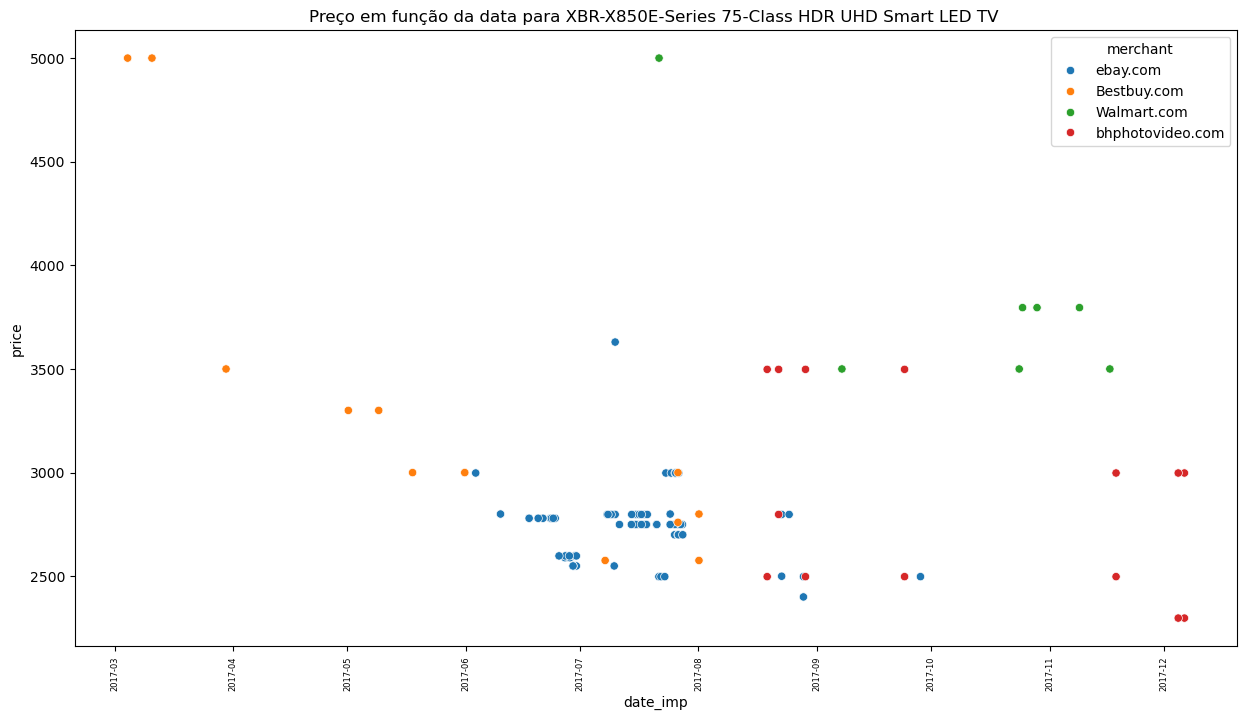

In [25]:
aux = df2[(df2['category_name'] == 'tv, television, video') & (df2['name'] == 'XBR-X850E-Series 75-Class HDR UHD Smart LED TV')]

plt.figure(figsize=(15, 8))
sns.scatterplot(x='date_imp', y='price', data=aux, hue='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.title('Preço em função da data para XBR-X850E-Series 75-Class HDR UHD Smart LED TV ')
plt.show;

In [26]:
aux1 = df2[(df2['category_name'] == 'tv, television, video') & (df2['merchant'] == 'ebay.com') & (df2['name'] == 'XBR-X850E-Series 75-Class HDR UHD Smart LED TV')]
aux1.T

,6806,6807,6808,6809,6810,6811,6812,6813,6814,6815,...,6878,6879,6880,6881,6882,6883,6884,6885,6886,6887
date_imp,2017-06-27 11:00:00,2017-06-28 04:00:00,2017-06-27 00:00:00,2017-06-28 08:00:00,2017-07-09 22:00:00,2017-06-29 13:00:00,2017-06-30 00:00:00,2017-06-29 03:00:00,2017-06-29 03:00:00,2017-07-27 19:00:00,...,2017-06-17 15:00:00,2017-06-23 16:00:00,2017-06-20 01:00:00,2017-06-23 11:00:00,2017-06-23 23:00:00,2017-06-21 06:00:00,2017-06-17 15:00:00,2017-06-20 00:00:00,2017-07-24 14:00:00,2017-07-10 04:00:00
category_name,"tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video",...,"tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video","tv, television, video"
name,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,...,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,XBR-X850E-Series 75-Class HDR UHD Smart LED TV
price,2589.52,2589.52,2589.52,2589.52,2549.52,2549.52,2549.52,2549.52,2549.52,2699.99,...,2779.52,2779.52,2779.52,2779.52,2779.52,2779.52,2779.52,2779.52,2799.99,3629.83
disc_price,2589.52,2589.52,2589.52,2589.52,2549.52,2549.52,2549.52,2549.52,2549.52,2699.99,...,2779.52,2779.52,2779.52,2779.52,2779.52,2779.52,2779.52,2779.52,2799.99,3629.83
merchant,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,...,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com,ebay.com
disc_percentage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
brand,Sony,Sony,Sony,Sony,Sony,Sony,Sony,Sony,Sony,Sony,...,Sony,Sony,Sony,Sony,Sony,Sony,Sony,Sony,Sony,Sony
p_description,"4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...",...,"4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro...","4K Ultra HD TVs,TV, Video & Home Audio,Electro..."
manufacturer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Determinando a demanda (ou quantidade vendida)

In [27]:
# neste caso, a demanda é a quantidade de produtos vendidos em determinado preço

In [28]:
df_demanda= aux1.groupby('price')['name'].count().reset_index(name='quantidade')

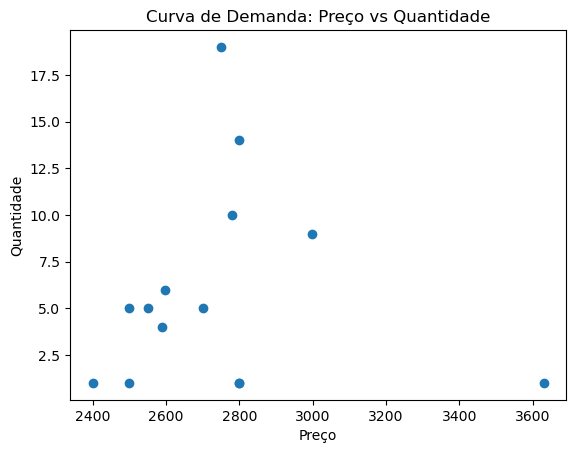

In [29]:
plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

### Determinando preço ótimo

In [30]:
# Preço ótimo - preço que resulta na maior receita conforme a demanda observada
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          2749.52
quantidade       19.00
receita       52240.88
Name: 7, dtype: float64


In [31]:
df_demanda.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
price,2399.99,2498.0,2499.99,2549.52,2589.52,2598.0,2699.99,2749.52,2779.52,2798.0,2799.99,2800.0,2998.0,3629.83
quantidade,1.00,5.0,1.00,5.00,4.00,6.0,5.00,19.00,10.00,14.0,1.00,1.0,9.0,1.00
receita,2399.99,12490.0,2499.99,12747.60,10358.08,15588.0,13499.95,52240.88,27795.20,39172.0,2799.99,2800.0,26982.0,3629.83


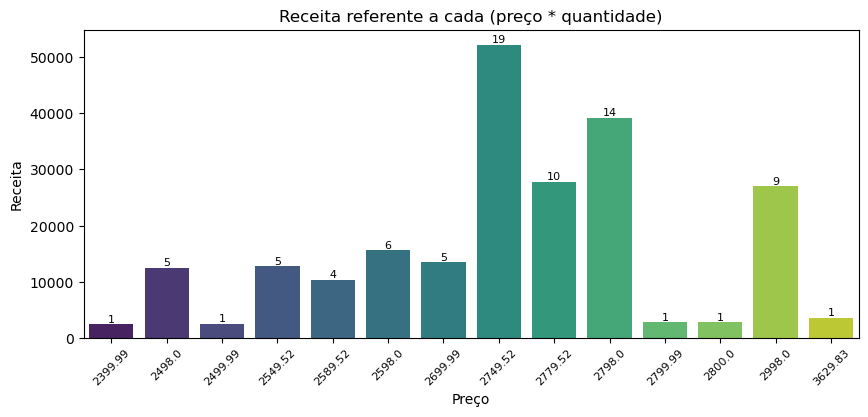

In [32]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

### Determinando a elasticidade

In [33]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.083
Method:                 Least Squares   F-statistic:                 0.0005745
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.981
Time:                        19:31:42   Log-Likelihood:                -43.149
No. Observations:                  14   AIC:                             90.30
Df Residuals:                      12   BIC:                             91.58
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5128     14.

### Determinando a curva resposta

In [34]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 2749.52  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 1924.66, Quantidade: 5.75, Elasticidade: 0.042
Preço: 2199.62, Quantidade: 5.79, Elasticidade: 0.048
Preço: 2474.57, Quantidade: 5.82, Elasticidade: 0.053
Preço: 2749.52, Quantidade: 5.86, Elasticidade: 0.059
Preço: 3024.47, Quantidade: 5.89, Elasticidade: 0.064
Preço: 3299.42, Quantidade: 5.93, Elasticidade: 0.070
Preço: 3574.38, Quantidade: 5.96, Elasticidade: 0.075


In [35]:
# como os resultados de R^2 e p-valor mostram, tanto no modelo linear quanto no log, o preço não explica de 
# maneira relevante e significativa a variação apresentada pela demanda. logo, os resultados das elasticidades
# fornecidas pelos modelos bem como as curvas respostas devem ser usados com parcimônia.

### Merchant escolhido: Bestbuy.com

In [36]:
aux21 = df2[(df2['category_name'] == 'tv, television, video') & (df2['merchant'] == 'Bestbuy.com') & (df2['name'] == 'XBR-X850E-Series 75-Class HDR UHD Smart LED TV')]

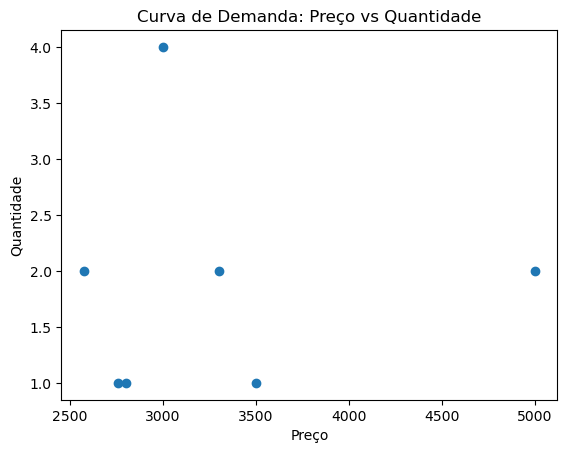

In [37]:
df_demanda= aux21.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [38]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          2999.99
quantidade        4.00
receita       11999.96
Name: 3, dtype: float64


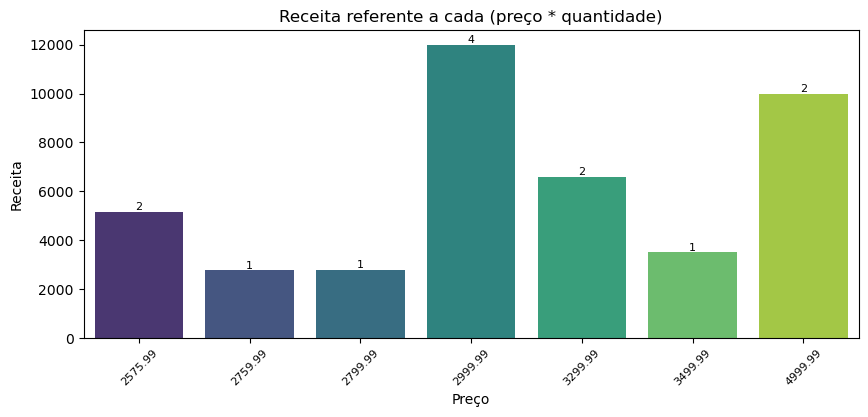

In [39]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [40]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.198
Method:                 Least Squares   F-statistic:                  0.008393
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.931
Time:                        19:31:43   Log-Likelihood:                -9.8545
No. Observations:                   7   AIC:                             23.71
Df Residuals:                       5   BIC:                             23.60
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6833      1.

In [41]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 2999.99  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 2099.99, Quantidade: 1.79, Elasticidade: 0.062
Preço: 2399.99, Quantidade: 1.81, Elasticidade: 0.070
Preço: 2699.99, Quantidade: 1.83, Elasticidade: 0.078
Preço: 2999.99, Quantidade: 1.84, Elasticidade: 0.086
Preço: 3299.99, Quantidade: 1.86, Elasticidade: 0.094
Preço: 3599.99, Quantidade: 1.87, Elasticidade: 0.102
Preço: 3899.99, Quantidade: 1.89, Elasticidade: 0.109


In [42]:
# como os resultados de R^2 e p-valor mostram, tanto no modelo linear quanto no log, o preço não explica de 
# maneira relevante e significativa a variação apresentada pela demanda. logo, os resultados das elasticidades
# fornecidas pelos modelos bem como as curvas respostas devem ser usados com parcimônia.

### Merchant escolhido: Walmart.com

In [43]:
aux31 = df2[(df2['category_name'] == 'tv, television, video') & (df2['merchant'] == 'Walmart.com') & (df2['name'] == 'XBR-X850E-Series 75-Class HDR UHD Smart LED TV')]

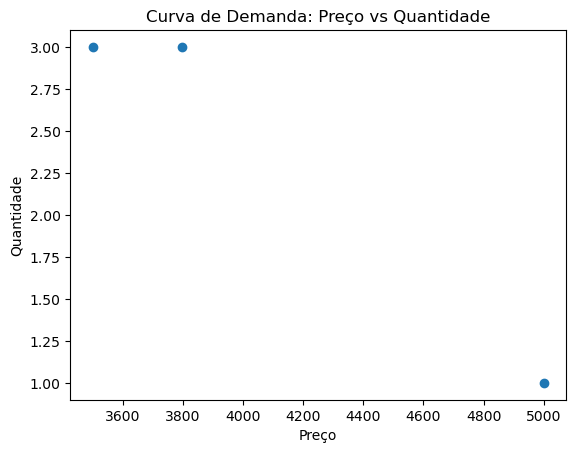

In [44]:
df_demanda= aux31.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [45]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          3796.0
quantidade        3.0
receita       11388.0
Name: 1, dtype: float64


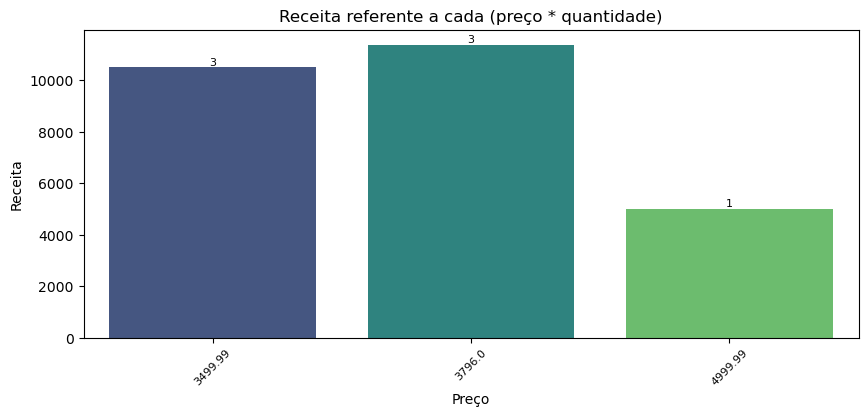

In [46]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [47]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     27.81
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.119
Time:                        19:31:45   Log-Likelihood:                0.96119
No. Observations:                   3   AIC:                             2.078
Df Residuals:                       1   BIC:                            0.2748
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1860      1.

In [48]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 3796.0  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 2657.20, Quantidade: 4.39, Elasticidade: -0.864
Preço: 3036.80, Quantidade: 3.85, Elasticidade: -1.126
Preço: 3416.40, Quantidade: 3.31, Elasticidade: -1.475
Preço: 3796.00, Quantidade: 2.77, Elasticidade: -1.960
Preço: 4175.60, Quantidade: 2.22, Elasticidade: -2.682
Preço: 4555.20, Quantidade: 1.68, Elasticidade: -3.869
Preço: 4934.80, Quantidade: 1.14, Elasticidade: -6.185


In [49]:
# resultados de R^2 e p-valor melhores que nos anteriores mas o p-valor mostra que o resultado obtido 
# não é estatisticamente significante.

### Merchant escolhido: bhphotovideo.com

In [50]:
aux41 = df2[(df2['category_name'] == 'tv, television, video') & (df2['merchant'] == 'bhphotovideo.com') & (df2['name'] == 'XBR-X850E-Series 75-Class HDR UHD Smart LED TV')]

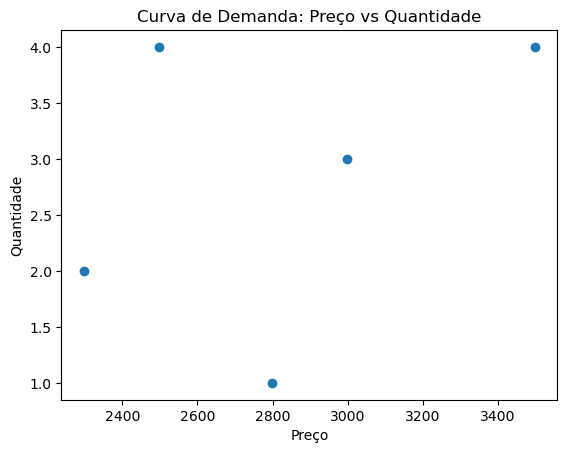

In [51]:
df_demanda= aux41.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [52]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          3498.0
quantidade        4.0
receita       13992.0
Name: 4, dtype: float64


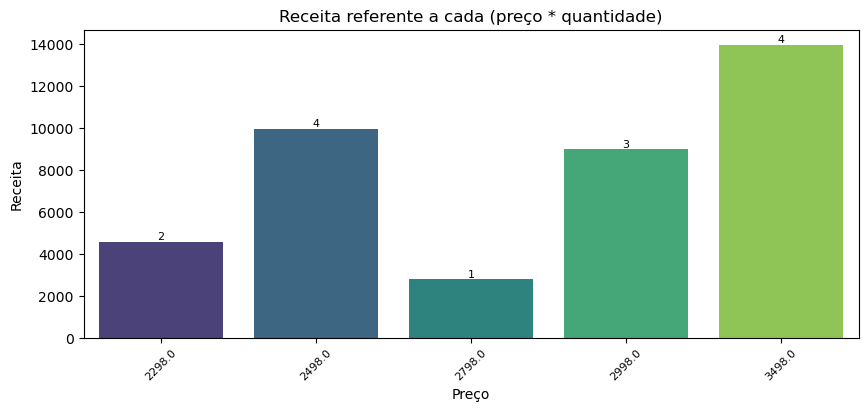

In [53]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [54]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                 -0.142
Method:                 Least Squares   F-statistic:                    0.5022
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.530
Time:                        19:31:46   Log-Likelihood:                -7.4764
No. Observations:                   5   AIC:                             18.95
Df Residuals:                       3   BIC:                             18.17
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1868      4.

In [55]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 3498.0  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 2448.60, Quantidade: 2.41, Elasticidade: 1.078
Preço: 2798.40, Quantidade: 2.78, Elasticidade: 1.067
Preço: 3148.20, Quantidade: 3.15, Elasticidade: 1.059
Preço: 3498.00, Quantidade: 3.52, Elasticidade: 1.053
Preço: 3847.80, Quantidade: 3.89, Elasticidade: 1.048
Preço: 4197.60, Quantidade: 4.26, Elasticidade: 1.044
Preço: 4547.40, Quantidade: 4.63, Elasticidade: 1.040


In [56]:
# como os resultados de R^2 e p-valor mostram, tanto no modelo linear quanto no log, o preço não explica de 
# maneira relevante e significativa a variação apresentada pela demanda. logo, os resultados das elasticidades
# fornecidas pelos modelos bem como as curvas respostas devem ser usados com parcimônia.

### Merchant escolhido: ebay.com, Bestbuy.com, Walmart.com, bhphotovideo.com

In [57]:
aux51 = df2[(df2['category_name'] == 'tv, television, video') & (df2['name'] == 'XBR-X850E-Series 75-Class HDR UHD Smart LED TV')]

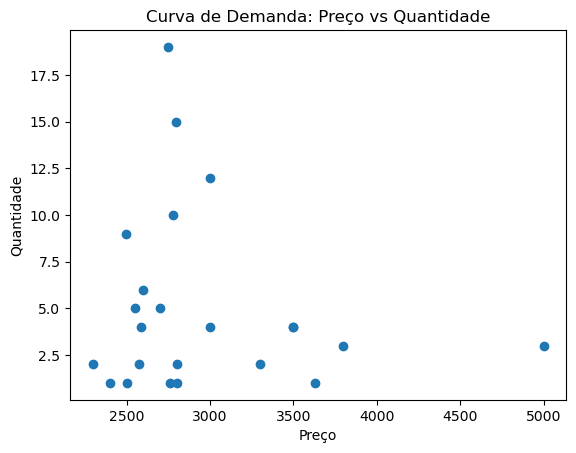

In [58]:
df_demanda= aux51.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [59]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          2749.52
quantidade       19.00
receita       52240.88
Name: 9, dtype: float64


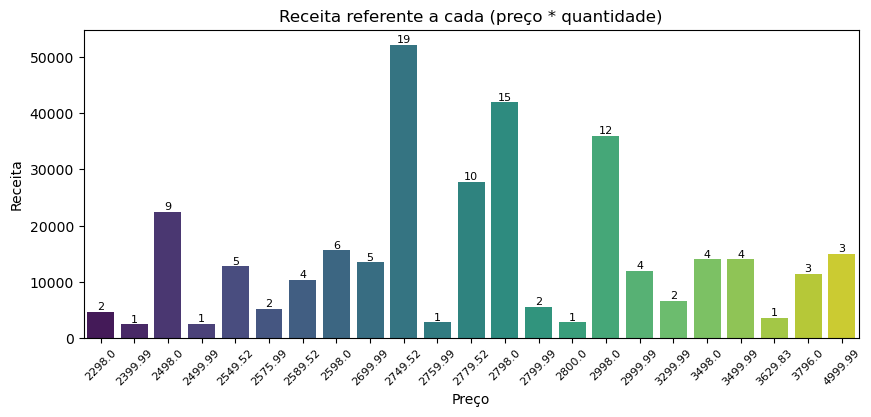

In [60]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [61]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.029
Method:                 Least Squares   F-statistic:                    0.3712
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.549
Time:                        19:31:48   Log-Likelihood:                -68.183
No. Observations:                  23   AIC:                             140.4
Df Residuals:                      21   BIC:                             142.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1687      5.

In [62]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 2749.52  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 1924.66, Quantidade: 6.14, Elasticidade: -0.331
Preço: 2199.62, Quantidade: 5.85, Elasticidade: -0.397
Preço: 2474.57, Quantidade: 5.56, Elasticidade: -0.470
Preço: 2749.52, Quantidade: 5.27, Elasticidade: -0.551
Preço: 3024.47, Quantidade: 4.98, Elasticidade: -0.641
Preço: 3299.42, Quantidade: 4.69, Elasticidade: -0.743
Preço: 3574.38, Quantidade: 4.40, Elasticidade: -0.858


## Análise com regressão não linear

In [63]:
preco = df_demanda['price'].values
quantidade = df_demanda['quantidade'].values

# curve_fit
p0 = [quantidade.max(), np.median(preco), np.std(preco)]
popt, pcov = curve_fit(gauss, preco, quantidade, p0=p0, maxfev=10000)
a_cf, mu_cf, sigma_cf = popt
se_cf = np.sqrt(np.diag(pcov))

# statsmodels (GenericLikelihoodModel)
class GaussModel(GenericLikelihoodModel):
    def nloglikeobs(self, params):
        a, mu, sigma = params
        yhat = gauss(preco, a, mu, sigma)
        resid = quantidade - yhat
        sigma_res = np.std(resid)
        return 0.5 * np.log(2*np.pi) + np.log(sigma_res) + 0.5*(resid/sigma_res)**2

mod = GaussModel(quantidade)
mod.endog_index = preco
res = mod.fit(start_params=p0, method="bfgs", disp=False, maxiter=10000)
a_sm, mu_sm, sigma_sm = res.params

# Elasticidades
df_demanda['elasticidade_curvefit'] = elasticity_gauss(df_demanda['price'], mu_cf, sigma_cf)
df_demanda['elasticidade_statsmodels'] = elasticity_gauss(df_demanda['price'], mu_sm, sigma_sm)

print("curve_fit params:", popt, "std err:", se_cf)
print(res.summary())

curve_fit params: [   7.96096748 2937.48666987  375.89069688] std err: [  1.98224551 119.16307648 119.5760835 ]
                              GaussModel Results                              
Dep. Variable:                      y   Log-Likelihood:                -66.246
Model:                     GaussModel   AIC:                             144.5
Method:            Maximum Likelihood   BIC:                             151.3
Date:                Tue, 23 Sep 2025                                         
Time:                        19:31:48                                         
No. Observations:                  23                                         
Df Residuals:                      20                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           7.96

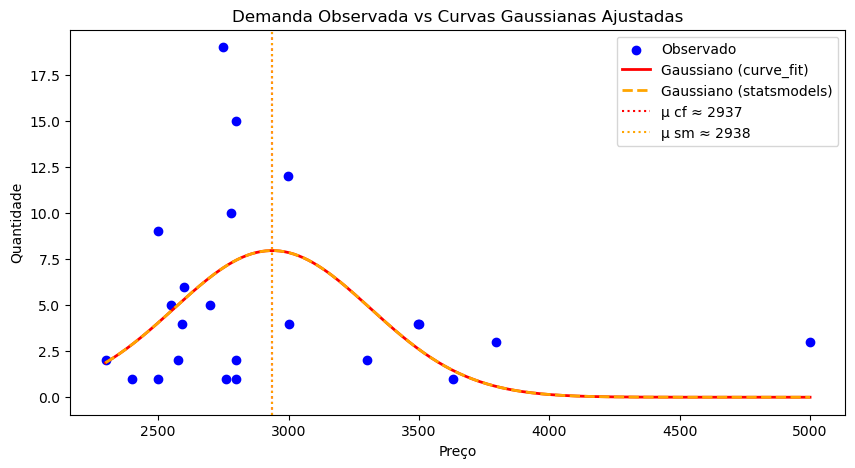

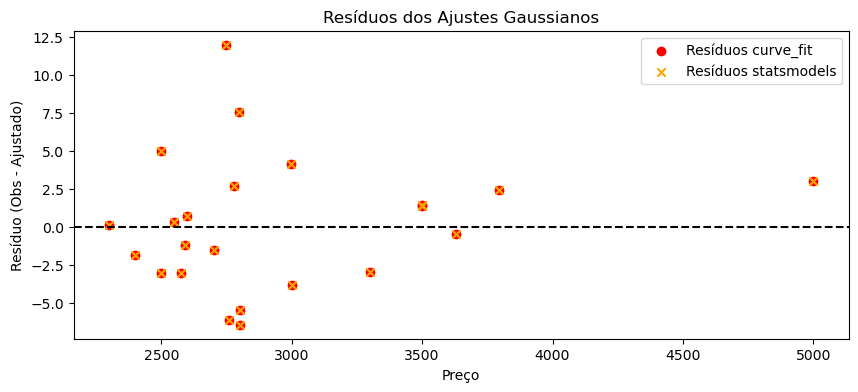

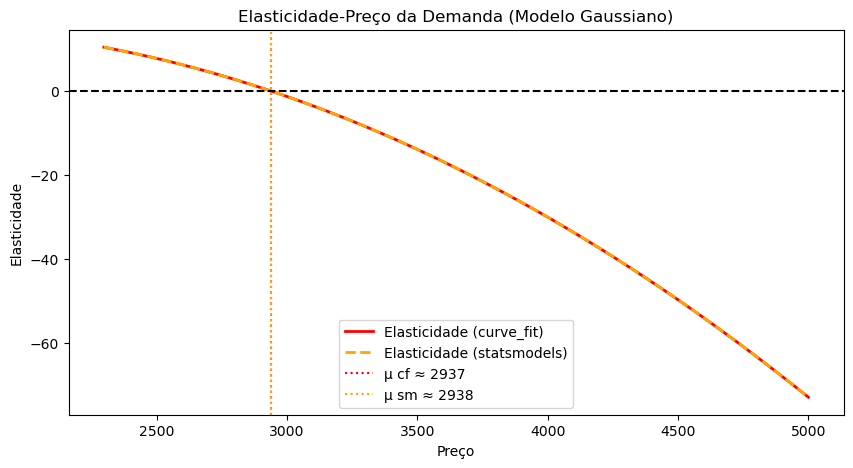

In [64]:
# Parâmetros estimados
a_cf, mu_cf, sigma_cf = popt  # do curve_fit
a_sm, mu_sm, sigma_sm = res.params  # do statsmodels

# Grid de preços para curvas suaves
preco_grid = np.linspace(df_demanda['price'].min(), df_demanda['price'].max(), 300)

# Previsões
q_pred_cf = gauss(preco_grid, a_cf, mu_cf, sigma_cf)
q_pred_sm = gauss(preco_grid, a_sm, mu_sm, sigma_sm)

# 1. Curva ajustada vs dados
plt.figure(figsize=(10,5))
plt.scatter(df_demanda['price'], df_demanda['quantidade'], color="blue", label="Observado")
plt.plot(preco_grid, q_pred_cf, color="red", linewidth=2, label="Gaussiano (curve_fit)")
plt.plot(preco_grid, q_pred_sm, color="orange", linestyle="--", linewidth=2, label="Gaussiano (statsmodels)")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Demanda Observada vs Curvas Gaussianas Ajustadas")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

# 2. Resíduos
q_fit_cf = gauss(df_demanda['price'], a_cf, mu_cf, sigma_cf)
q_fit_sm = gauss(df_demanda['price'], a_sm, mu_sm, sigma_sm)
residuos_cf = df_demanda['quantidade'] - q_fit_cf
residuos_sm = df_demanda['quantidade'] - q_fit_sm

plt.figure(figsize=(10,4))
plt.axhline(0, color="black", linestyle="--")
plt.scatter(df_demanda['price'], residuos_cf, color="red", label="Resíduos curve_fit")
plt.scatter(df_demanda['price'], residuos_sm, color="orange", marker="x", label="Resíduos statsmodels")
plt.title("Resíduos dos Ajustes Gaussianos")
plt.xlabel("Preço")
plt.ylabel("Resíduo (Obs - Ajustado)")
plt.legend()
plt.show()

# 3. Elasticidade vs preço
elasticidade_cf = elasticity_gauss(preco_grid, mu_cf, sigma_cf)
elasticidade_sm = elasticity_gauss(preco_grid, mu_sm, sigma_sm)

plt.figure(figsize=(10,5))
plt.plot(preco_grid, elasticidade_cf, color="red", linewidth=2, label="Elasticidade (curve_fit)")
plt.plot(preco_grid, elasticidade_sm, color="orange", linestyle="--", linewidth=2, label="Elasticidade (statsmodels)")
plt.axhline(0, color="black", linestyle="--")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Elasticidade-Preço da Demanda (Modelo Gaussiano)")
plt.xlabel("Preço")
plt.ylabel("Elasticidade")
plt.legend()
plt.show()

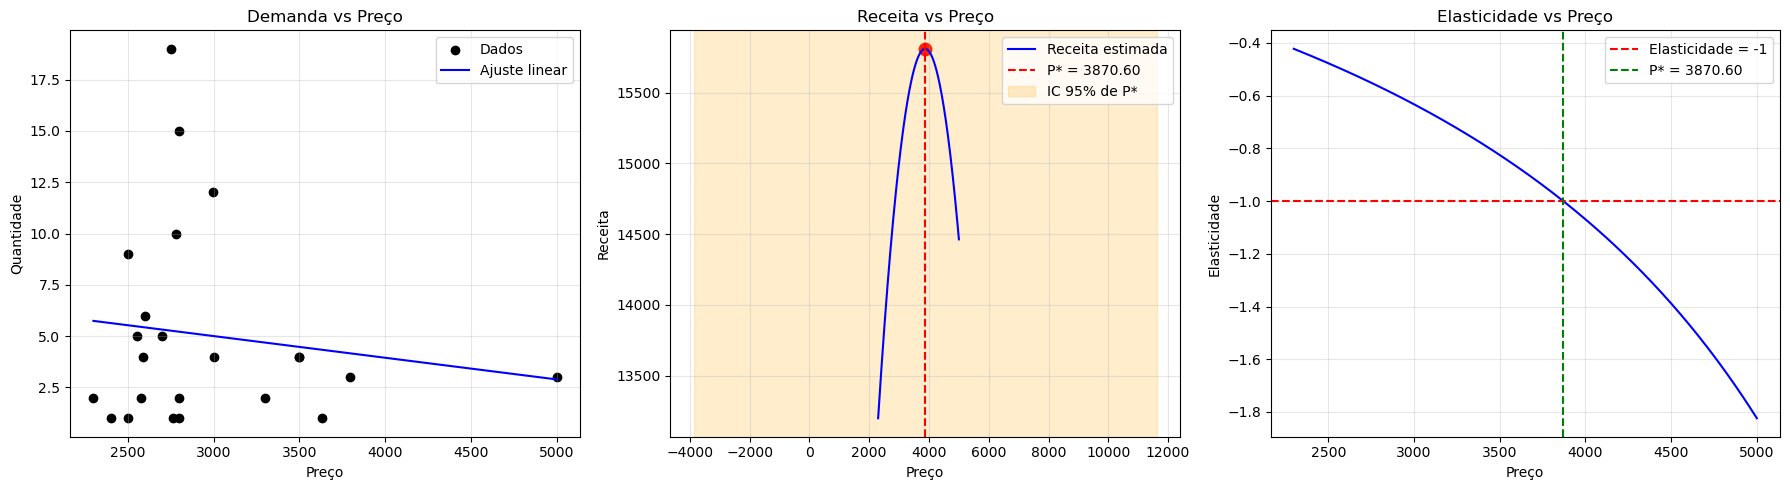

Resultados do ajuste linear:
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.029
Method:                 Least Squares   F-statistic:                    0.3712
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.549
Time:                        19:31:50   Log-Likelihood:                -68.183
No. Observations:                  23   AIC:                             140.4
Df Residuals:                      21   BIC:                             142.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1687  

In [65]:
X = sm.add_constant(df_demanda['price'])
y = df_demanda["quantidade"]
model = sm.OLS(y, X).fit()

# Coeficientes da regressão
beta0, beta1 = model.params

# Preço ótimo (maximiza a receita)
P_star = -beta0 / (2 * beta1)

# Gradiente para delta method
grad = np.array([-1 / (2 * beta1), beta0 / (2 * beta1**2)])
cov = model.cov_params()
var_Pstar = grad.T @ cov @ grad
se_Pstar = np.sqrt(var_Pstar)
ci_low, ci_high = P_star - 1.96 * se_Pstar, P_star + 1.96 * se_Pstar

precos = np.linspace(df_demanda['price'].min(), df_demanda['price'].max(), 200)
quantidades_pred = beta0 + beta1 * precos
receita = precos * quantidades_pred
elasticidade = beta1 * (precos / quantidades_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Demanda
axes[0].scatter(df_demanda['price'], df_demanda["quantidade"], label="Dados", color="black")
axes[0].plot(precos, quantidades_pred, color="blue", label="Ajuste linear")
axes[0].set_title("Demanda vs Preço")
axes[0].set_xlabel("Preço")
axes[0].set_ylabel("Quantidade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Receita
axes[1].plot(precos, receita, color="blue", label="Receita estimada")
axes[1].axvline(P_star, color="red", linestyle="--", label=f"P* = {P_star:.2f}")
axes[1].scatter(P_star, P_star * (beta0 + beta1 * P_star), color="red", s=80)
axes[1].axvspan(ci_low, ci_high, color="orange", alpha=0.2, label="IC 95% de P*")
axes[1].set_title("Receita vs Preço")
axes[1].set_xlabel("Preço")
axes[1].set_ylabel("Receita")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Elasticidade
axes[2].plot(precos, elasticidade, color="blue")
axes[2].axhline(-1, color="red", linestyle="--", label="Elasticidade = -1")
axes[2].axvline(P_star, color="green", linestyle="--", label=f"P* = {P_star:.2f}")
axes[2].set_title("Elasticidade vs Preço")
axes[2].set_xlabel("Preço")
axes[2].set_ylabel("Elasticidade")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Resultados do ajuste linear:")
print(model.summary())
print(f"\nPreço ótimo (P*): {P_star:.2f}")
print(f"Erro-padrão de P*: {se_Pstar:.2f}")
print(f"IC 95% para P*: [{ci_low:.2f}, {ci_high:.2f}]")

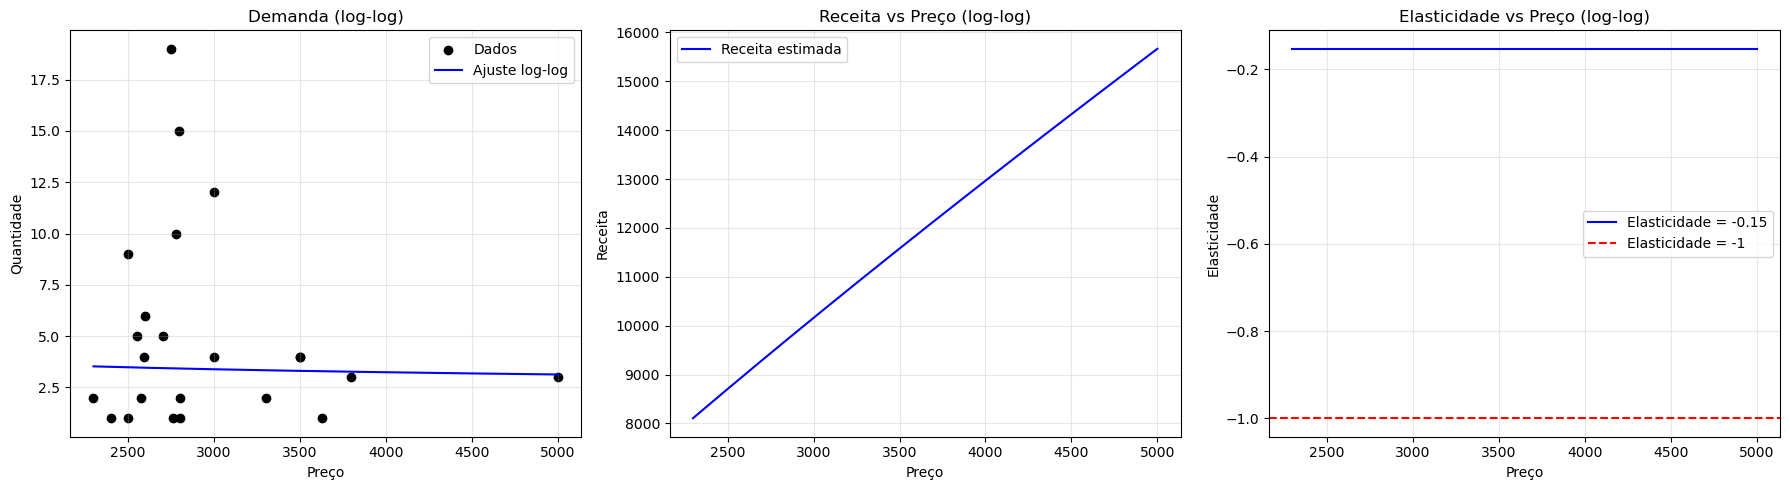

Resultados do ajuste log-log:
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.047
Method:                 Least Squares   F-statistic:                   0.01918
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.891
Time:                        19:31:51   Log-Likelihood:                -29.957
No. Observations:                  23   AIC:                             63.91
Df Residuals:                      21   BIC:                             66.18
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4420 

In [66]:
df_log = df_demanda[(df_demanda['price'] > 0) & (df_demanda['quantidade'] > 0)].copy()
X = np.log(df_log['price'])
y = np.log(df_log["quantidade"])
X = sm.add_constant(X)

model_loglog = sm.OLS(y, X).fit()
beta0, beta1 = model_loglog.params  # intercepto e elasticidade

precos = np.linspace(df_log['price'].min(), df_log['price'].max(), 200)
quantidades_pred = np.exp(beta0 + beta1 * np.log(precos))
receita = precos * quantidades_pred
elasticidade = np.repeat(beta1, len(precos))  # constante no modelo log-log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Demanda
axes[0].scatter(df_log['price'], df_log["quantidade"], label="Dados", color="black")
axes[0].plot(precos, quantidades_pred, color="blue", label="Ajuste log-log")
axes[0].set_title("Demanda (log-log)")
axes[0].set_xlabel("Preço")
axes[0].set_ylabel("Quantidade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Receita
axes[1].plot(precos, receita, color="blue", label="Receita estimada")
axes[1].set_title("Receita vs Preço (log-log)")
axes[1].set_xlabel("Preço")
axes[1].set_ylabel("Receita")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Elasticidade
axes[2].plot(precos, elasticidade, color="blue", label=f"Elasticidade = {beta1:.2f}")
axes[2].axhline(-1, color="red", linestyle="--", label="Elasticidade = -1")
axes[2].set_title("Elasticidade vs Preço (log-log)")
axes[2].set_xlabel("Preço")
axes[2].set_ylabel("Elasticidade")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Resultados do ajuste log-log:")
print(model_loglog.summary())
print(f"\nElasticidade-preço estimada (beta1): {beta1:.3f}")

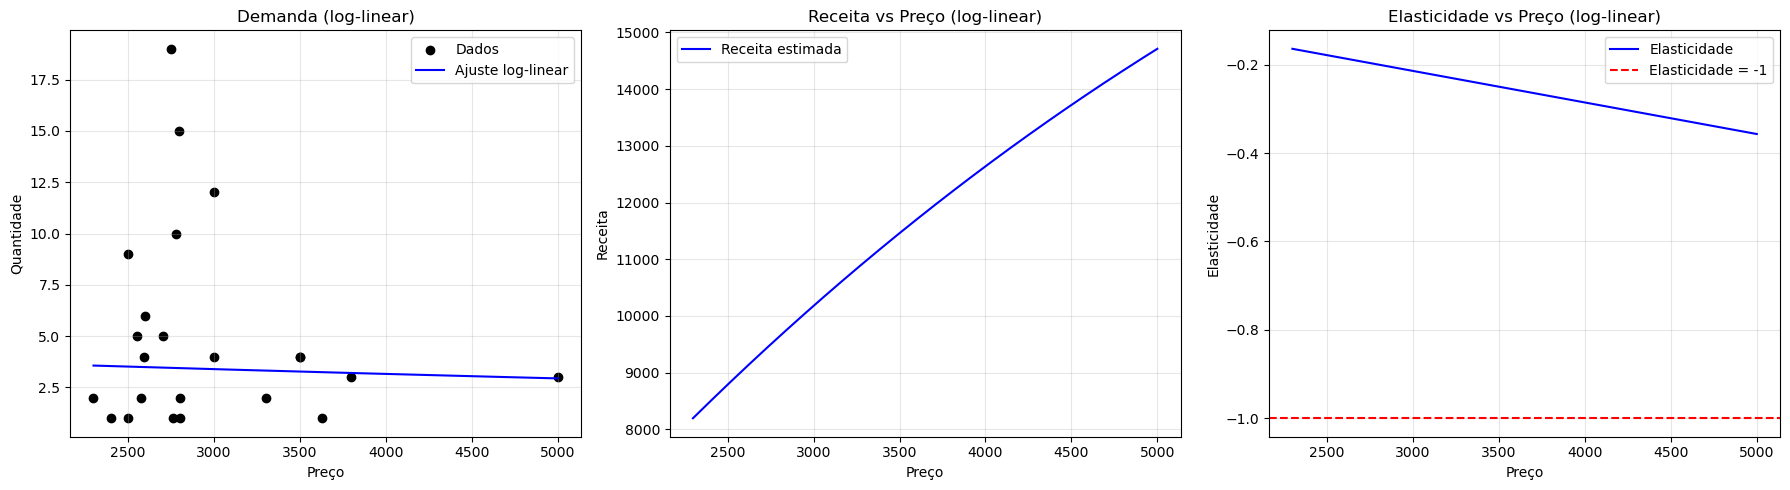

Resultados do ajuste log-linear:
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.045
Method:                 Least Squares   F-statistic:                   0.04721
Date:                Tue, 23 Sep 2025   Prob (F-statistic):              0.830
Time:                        19:31:52   Log-Likelihood:                -29.941
No. Observations:                  23   AIC:                             63.88
Df Residuals:                      21   BIC:                             66.15
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.43

In [67]:
df_loglin = df_demanda[(df_demanda['price'] > 0) & (df_demanda['quantidade'] > 0)].copy()   # remover valores não positivos
X = df_loglin['price']
y = np.log(df_loglin['quantidade'])
X = sm.add_constant(X)

model_loglin = sm.OLS(y, X).fit()
beta0, beta1 = model_loglin.params

precos = np.linspace(df_loglin['price'].min(), df_loglin['price'].max(), 200)
quantidades_pred = np.exp(beta0 + beta1 * precos)
receita = precos * quantidades_pred
elasticidade = beta1 * precos  # varia com o preço

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Demanda
axes[0].scatter(df_loglin['price'], df_loglin['quantidade'], label="Dados", color="black")
axes[0].plot(precos, quantidades_pred, color="blue", label="Ajuste log-linear")
axes[0].set_title("Demanda (log-linear)")
axes[0].set_xlabel("Preço")
axes[0].set_ylabel("Quantidade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Receita
axes[1].plot(precos, receita, color="blue", label="Receita estimada")
axes[1].set_title("Receita vs Preço (log-linear)")
axes[1].set_xlabel("Preço")
axes[1].set_ylabel("Receita")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Elasticidade
axes[2].plot(precos, elasticidade, color="blue", label="Elasticidade")
axes[2].axhline(-1, color="red", linestyle="--", label="Elasticidade = -1")
axes[2].set_title("Elasticidade vs Preço (log-linear)")
axes[2].set_xlabel("Preço")
axes[2].set_ylabel("Elasticidade")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Resultados do ajuste log-linear:")
print(model_loglin.summary())